# Fibrilação Atrial em ECGs de Longa Duração

- Pedro Paulo Camargo
- Henrique Badin

## 1. Preparação do Ambiente

In [4]:
import sys
import subprocess

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'wfdb', 'ipywidgets'])

# Imports
from pathlib import Path
from collections import defaultdict
import textwrap
import warnings

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, clear_output
from scipy.signal import find_peaks

from scipy.signal import butter, filtfilt
from scipy.stats import iqr
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from IPython.display import display

# Configurações de visualização e limpeza de warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)


## 2. Visão Geral da Base de ECGs

### 2.1 Registros Disponíveis

Nesta etapa, o notebook localiza automaticamente os arquivos WFDB válidos na pasta `data/` e monta uma visão inicial dos registros que poderão ser analisados.

In [5]:
# Configurações centrais da análise
# DATA_DIR: pasta onde estão os registros WFDB (.hea/.dat/.atr)
# SELECTED_RECORD_INDEX: índice do exame escolhido para análise detalhada
# WINDOW_SECONDS: duração padrão das janelas exibidas nos navegadores interativos
DATA_DIR = Path('data')
ANNOTATION_EXTENSION = 'atr'
SELECTED_RECORD_INDEX = 0
WINDOW_SECONDS = 5


In [6]:
# ============================================================
# Funções auxiliares de leitura, limpeza e sumarização da base
# ============================================================

def list_wfdb_records(data_dir: Path):
    """Lista automaticamente os registros WFDB válidos na pasta informada."""
    hea_files = sorted(data_dir.rglob('*.hea'))
    records = []
    seen = set()

    for hea_file in hea_files:
        record_base = hea_file.with_suffix('')
        dat_file = record_base.with_suffix('.dat')

        if dat_file.exists() and str(record_base) not in seen:
            records.append(record_base)
            seen.add(str(record_base))

    return records


def clean_note(note):
    """Remove caracteres nulos e espaços extras das anotações."""
    return str(note).replace('\x00', '').strip()


def has_annotation(record_path: Path, extension: str = ANNOTATION_EXTENSION):
    """Verifica se o registro possui o arquivo de anotação esperado."""
    return record_path.with_suffix(f'.{extension}').exists()


def load_record(record_path: Path, annotation_extension: str = ANNOTATION_EXTENSION):
    """Carrega o sinal e, se existir, as anotações do registro."""
    record = wfdb.rdrecord(str(record_path))
    annotations = None

    if has_annotation(record_path, annotation_extension):
        annotations = wfdb.rdann(str(record_path), annotation_extension)

    return record, annotations


def get_rhythm_indices(annotations):
    """Retorna apenas os índices das anotações que representam mudança explícita de ritmo."""
    if annotations is None:
        return []

    rhythm_indices = []
    for i, note in enumerate(annotations.aux_note):
        note = clean_note(note)
        if note.startswith('('):
            rhythm_indices.append(i)

    return rhythm_indices


def summarize_rhythms(record, annotations):
    """Agrupa contagem e tempo total por ritmo para um registro."""
    stats = {}
    timeline = []
    rhythm_indices = get_rhythm_indices(annotations)

    for position, current_idx in enumerate(rhythm_indices):
        rhythm_name = clean_note(annotations.aux_note[current_idx]).replace('(', '')
        start_sample = int(annotations.sample[current_idx])

        # O fim do ritmo atual é definido pela próxima anotação de mudança
        if position + 1 < len(rhythm_indices):
            end_sample = int(annotations.sample[rhythm_indices[position + 1]])
        else:
            end_sample = int(record.sig_len)

        duration_seconds = (end_sample - start_sample) / record.fs

        if rhythm_name not in stats:
            stats[rhythm_name] = {'contagem': 0, 'tempo_total_s': 0.0}

        stats[rhythm_name]['contagem'] += 1
        stats[rhythm_name]['tempo_total_s'] += duration_seconds
        timeline.append(f'{rhythm_name} ({duration_seconds:.1f}s)')

    return stats, timeline


def signal_dataframe(record):
    """Converte o sinal para DataFrame, independentemente do número de canais."""
    column_names = [f'Canal_{i + 1}' for i in range(record.n_sig)]
    return pd.DataFrame(record.p_signal, columns=column_names)


def find_flatlines(signal_column, sampling_frequency, limit_seconds=2):
    """Encontra trechos com valor 0.0 contínuo por pelo menos `limit_seconds`."""
    series = pd.Series(signal_column)
    is_zero = series.eq(0.0)
    blocks = is_zero.ne(is_zero.shift()).cumsum()
    block_sizes = is_zero.groupby(blocks).sum()

    minimum_samples = int(limit_seconds * sampling_frequency)
    real_flatlines = block_sizes[block_sizes >= minimum_samples]

    event_count = int(len(real_flatlines))
    total_time_seconds = float(real_flatlines.sum() / sampling_frequency)

    return event_count, total_time_seconds


def extract_afib_episodes(record, annotations):
    """Extrai tabela com episódios de AFIB para um registro."""
    if annotations is None:
        return pd.DataFrame()

    episodes = []
    rhythm_indices = [i for i, note in enumerate(annotations.aux_note) if clean_note(note) != '']

    for position, current_idx in enumerate(rhythm_indices):
        current_note = clean_note(annotations.aux_note[current_idx])

        if '(AFIB' not in current_note:
            continue

        start_sample = int(annotations.sample[current_idx])

        # O episódio termina quando uma nova anotação de ritmo aparece
        if position + 1 < len(rhythm_indices):
            next_idx = rhythm_indices[position + 1]
            end_sample = int(annotations.sample[next_idx])
            next_rhythm = clean_note(annotations.aux_note[next_idx]).replace('(', '')
        else:
            end_sample = int(record.sig_len)
            next_rhythm = 'FIM DO EXAME'

        duration_seconds = (end_sample - start_sample) / record.fs
        duration_minutes = duration_seconds / 60

        episodes.append({
            'Início (s)': round(start_sample / record.fs, 2),
            'Fim (s)': round(end_sample / record.fs, 2),
            'Duração (s)': round(duration_seconds, 2),
            'Duração (min)': round(duration_minutes, 2),
            'Terminou em': next_rhythm
        })

    return pd.DataFrame(episodes)


def detect_r_peaks(signal, sampling_frequency, min_distance_seconds=0.25):
    """Detecta picos R tentando automaticamente as duas polaridades do sinal."""
    if len(signal) == 0:
        return np.array([], dtype=int), 1

    # A distância mínima entre picos evita contagens irreais em alta frequência.
    distance = max(1, int(min_distance_seconds * sampling_frequency))
    threshold = max(0.20 * np.nanstd(signal), 0.05)
    prominence = max(0.10 * np.nanstd(signal), 0.02)

    pos_idx, _ = find_peaks(signal, height=threshold, distance=distance, prominence=prominence)
    neg_idx, _ = find_peaks(-signal, height=threshold, distance=distance, prominence=prominence)

    def score(indices):
        if len(indices) == 0:
            return -np.inf
        mean_amplitude = np.mean(np.abs(signal[indices]))
        if len(indices) == 1:
            return mean_amplitude
        rr = np.diff(indices) / sampling_frequency

        # Favorece séries de RR fisiologicamente plausíveis para reduzir detecções espúrias.
        plausible_rr = np.mean((rr >= 60 / 220) & (rr <= 60 / 35))
        return mean_amplitude + plausible_rr

    if score(neg_idx) > score(pos_idx):
        return neg_idx, -1
    return pos_idx, 1


def first_index_matching(annotations, token):
    """Retorna o primeiro índice de anotação que contenha o token informado."""
    if annotations is None:
        return None
    for i, note in enumerate(annotations.aux_note):
        if token in clean_note(note):
            return i
    return None


def find_normal_to_afib_transition(annotations):
    """Procura a primeira transição explícita de ritmo normal para AFIB."""
    if annotations is None:
        return None, None

    rhythm_indices = get_rhythm_indices(annotations)
    for i in range(len(rhythm_indices) - 1):
        current_note = clean_note(annotations.aux_note[rhythm_indices[i]])
        next_note = clean_note(annotations.aux_note[rhythm_indices[i + 1]])

        if '(N' in current_note and '(AFIB' in next_note:
            return rhythm_indices[i], rhythm_indices[i + 1]

    return None, None


# ============================================================
# Montagem do catálogo inicial de registros disponíveis
# ============================================================
record_paths = list_wfdb_records(DATA_DIR)

if not record_paths:
    raise FileNotFoundError(
        f'Nenhum registro WFDB válido foi encontrado em {DATA_DIR.resolve()}. '
        'Verifique se a pasta existe e contém pares .hea/.dat.'
    )

record_catalog = pd.DataFrame({
    'Índice': range(len(record_paths)),
    'Registro': [path.name for path in record_paths],
    'Caminho base': [str(path) for path in record_paths],
    'Tem .atr?': [has_annotation(path) for path in record_paths],
})

print(f'Total de registros encontrados em "{DATA_DIR}": {len(record_paths)}')
display(record_catalog)


Total de registros encontrados em "data": 2


,Índice,Registro,Caminho base,Tem .atr?
0,0,00,data\00,True
1,1,01,data\01,True


### 2.2 Resumo Registros da Pasta

Aqui é gerado um painel comparativo com duração, presença de anotações, episódios de AFIB, eventos de ruído e indícios de flatline para todos os exames encontrados.

In [7]:
# Consolidação global de todos os exames da pasta
# Para cada registro, são resumidos canais, duração, AFIB, ruído e possíveis flatlines.
all_record_rows = []
global_rhythm_stats = defaultdict(lambda: {'episodios': 0, 'tempo_total_s': 0.0})

for record_path in record_paths:
    record, annotations = load_record(record_path)
    df_signal = signal_dataframe(record)
    rhythm_stats, timeline = summarize_rhythms(record, annotations)
    afib_df = extract_afib_episodes(record, annotations)

    # Avaliação simples de qualidade do sinal por canal
    flatline_summary = {}
    for channel_name in df_signal.columns:
        events, total_time = find_flatlines(df_signal[channel_name], record.fs)
        flatline_summary[channel_name] = f'{events} evento(s) / {total_time:.1f}s'

    # Contagem de marcações explícitas de ruído no arquivo de anotações
    noise_count = 0
    if annotations is not None:
        noise_count = sum(1 for symbol in annotations.symbol if symbol == "|")

    # Acumula estatísticas globais por tipo de ritmo
    for rhythm_name, values in rhythm_stats.items():
        global_rhythm_stats[rhythm_name]['episodios'] += values['contagem']
        global_rhythm_stats[rhythm_name]['tempo_total_s'] += values['tempo_total_s']

    all_record_rows.append({
        'Registro': record_path.name,
        'Canais': record.n_sig,
        'Frequência (Hz)': record.fs,
        'Duração (min)': round(record.sig_len / record.fs / 60, 2),
        'Tem anotação .atr': annotations is not None,
        'Episódios AFIB': int(len(afib_df)) if not afib_df.empty else 0,
        'Tempo total AFIB (min)': round(afib_df['Duração (min)'].sum(), 2) if not afib_df.empty else 0.0,
        'Eventos de ruído (|)': int(noise_count),
        'Ritmos detectados': ', '.join(rhythm_stats.keys()) if rhythm_stats else 'Sem mudança de ritmo explícita',
        **flatline_summary,
    })

# Gera as duas saídas principais: visão por registro e consolidado por ritmo.
summary_all_records = pd.DataFrame(all_record_rows).sort_values('Registro').reset_index(drop=True)
global_rhythm_df = pd.DataFrame([
    {
        'Ritmo': rhythm_name,
        'Episódios': values['episodios'],
        'Tempo total (min)': round(values['tempo_total_s'] / 60, 2)
    }
    for rhythm_name, values in global_rhythm_stats.items()
]).sort_values(['Tempo total (min)', 'Episódios'], ascending=False)

print('=== PAINEL CONSOLIDADO DOS REGISTROS ENCONTRADOS ===')
display(summary_all_records.T)

print('\n=== CONSOLIDADO GLOBAL DOS RITMOS ANOTADOS ===')
if global_rhythm_df.empty:
    print('Nenhuma mudança de ritmo explícita foi encontrada nas anotações.')
else:
    display(global_rhythm_df)


=== PAINEL CONSOLIDADO DOS REGISTROS ENCONTRADOS ===


,0,1
Registro,00,01
Canais,2,2
Frequência (Hz),128,128
Duração (min),1258.0,1234.0
Tem anotação .atr,True,True
Episódios AFIB,44,53
Tempo total AFIB (min),134.9,371.77
Eventos de ruído (|),0,0
Ritmos detectados,"N, AFIB, VT","N, AB, AFIB, SVTA, T, B, SBR"
Canal_1,0 evento(s) / 0.0s,0 evento(s) / 0.0s



=== CONSOLIDADO GLOBAL DOS RITMOS ANOTADOS ===


,Ritmo,Episódios,Tempo total (min)
0,N,462,1330.40
1,AFIB,97,1108.01
3,AB,293,27.59
7,SBR,83,10.04
6,B,16,1.76
4,SVTA,25,0.96
5,T,6,0.88
2,VT,40,0.69


## 3. Análise Detalhada do Registro Selecionado

A partir deste ponto, o notebook sai da visão global da base e aprofunda a investigação em **um único exame**, definido por `SELECTED_RECORD_INDEX`.

### 3.1 Contexto e metadados do registro selecionado

Esta subcategoria resume os principais metadados do exame escolhido e exibe uma amostra inicial do sinal para contextualizar as etapas seguintes.

In [8]:
# Valida o índice informado e carrega o registro escolhido para análise aprofundada.
if SELECTED_RECORD_INDEX >= len(record_paths):
    raise IndexError(
        f'SELECTED_RECORD_INDEX={SELECTED_RECORD_INDEX} é inválido para {len(record_paths)} registro(s).'
    )

selected_record_path = record_paths[SELECTED_RECORD_INDEX]
record, annotations = load_record(selected_record_path)
df_signal = signal_dataframe(record)

# Quando houver mais de um canal, escolhemos automaticamente o segundo como padrão de plot.
plot_channel = 1 if record.n_sig > 1 else 0

print(f'Registro selecionado: {selected_record_path.name}')
print(f'Caminho base: {selected_record_path}')
print(f'Frequência de amostragem: {record.fs} Hz')
print(f'Número de canais: {record.n_sig}')
print(f'Duração aproximada: {record.sig_len / record.fs / 3600:.2f} horas')
print(f'Canal principal para plots automáticos: Canal_{plot_channel + 1}')
print(f'Anotação .{ANNOTATION_EXTENSION} carregada? {annotations is not None}')

# Exibe as primeiras amostras do sinal já organizado em DataFrame.
display(df_signal.head())


Registro selecionado: 00
Caminho base: data\00
Frequência de amostragem: 128 Hz
Número de canais: 2
Duração aproximada: 20.97 horas
Canal principal para plots automáticos: Canal_2
Anotação .atr carregada? True


,Canal_1,Canal_2
0,-0.00599,0.01734
1,-0.01198,0.02312
2,0.00599,0.01734
3,0.00000,0.01734
4,-0.01198,0.01734


### 3.2 Estatísticas descritivas e checagem de qualidade do sinal

Nesta etapa, avaliamos a distribuição dos sinais, a presença de valores ausentes, trechos de flatline e marcações de ruído nas anotações.

In [9]:
# Parte 1 — Estatísticas descritivas por canal
print('=== 1. ESTATÍSTICAS DESCRITIVAS DOS SINAIS (mV) ===')
display(df_signal.describe())

# Parte 2 — Verificação de integridade estrutural do DataFrame
print('\n=== 2. VALORES AUSENTES (NaN) POR CANAL ===')
print(df_signal.isna().sum())

# Parte 3 — Busca por trechos com flatline prolongado, que podem indicar problema de aquisição
print('\n=== 3. FLATLINES (zeros absolutos contínuos) ===')
for channel_name in df_signal.columns:
    events, total_time = find_flatlines(df_signal[channel_name], record.fs)
    print(f'{channel_name}: {events} evento(s) de flatline (>2s) | Tempo total: {total_time:.1f}s')

# Parte 4 — Consulta às marcações explícitas de ruído extremo presentes no arquivo de anotações
print('\n=== 4. ANOTAÇÕES DE SINAL ILEGÍVEL / RUÍDO (símbolo "|") ===')
if annotations is None:
    print('O registro selecionado não possui arquivo de anotações carregado.')
else:
    noise_events = [i for i, symbol in enumerate(annotations.symbol) if symbol == '|']
    if noise_events:
        print(f'Foram encontrados {len(noise_events)} momento(s) marcados como ruído extremo.')
    else:
        print('Nenhum momento de ruído extremo foi explicitamente marcado com "|" neste registro.')


=== 1. ESTATÍSTICAS DESCRITIVAS DOS SINAIS (mV) ===


,Canal_1,Canal_2
count,9.661440e+06,9.661440e+06
mean,-4.068252e-03,8.943039e-03
std,1.359463e-01,3.234250e-01
min,-4.714127e+00,-5.144211e+00
25%,-7.786996e-02,5.780013e-03
50%,-1.197999e-02,5.780013e-02
75%,5.390997e-02,1.213803e-01
max,3.785678e+00,2.392925e+00



=== 2. VALORES AUSENTES (NaN) POR CANAL ===
Canal_1    0
Canal_2    0
dtype: int64

=== 3. FLATLINES (zeros absolutos contínuos) ===
Canal_1: 0 evento(s) de flatline (>2s) | Tempo total: 0.0s
Canal_2: 0 evento(s) de flatline (>2s) | Tempo total: 0.0s

=== 4. ANOTAÇÕES DE SINAL ILEGÍVEL / RUÍDO (símbolo "|") ===
Nenhum momento de ruído extremo foi explicitamente marcado com "|" neste registro.


### 3.3 Linha do tempo dos ritmos anotados

Aqui é montado um resumo textual das mudanças de ritmo anotadas ao longo do exame selecionado, permitindo entender a sequência e a duração relativa de cada padrão identificado.

In [10]:
# Resume a quantidade e a duração total de cada ritmo anotado no exame selecionado.
rhythm_stats, timeline = summarize_rhythms(record, annotations)

print('=== RESUMO DAS ANOTAÇÕES DE RITMO NO EXAME SELECIONADO ===\n')
if not rhythm_stats:
    print('Nenhuma mudança explícita de ritmo foi encontrada nas anotações desse registro.')
else:
    total_exam_time = 0.0
    for rhythm_name, values in rhythm_stats.items():
        episode_count = values['contagem']
        total_seconds = values['tempo_total_s']
        total_exam_time += total_seconds

        minutes = int(total_seconds // 60)
        seconds = total_seconds % 60
        print(
            f'🔸 {rhythm_name}: {episode_count} episódio(s) | '
            f'Tempo total: {minutes}m {seconds:.1f}s ({total_seconds:.1f}s)'
        )

    print('-' * 60)
    total_minutes = int(total_exam_time // 60)
    print(f'Duração total analisada: {total_minutes}m {total_exam_time % 60:.1f}s')
    print('=' * 60 + '\n')

    # O texto abaixo funciona como um "mapa narrativo" da evolução do exame.
    print('=== SEQUÊNCIA TEMPORAL DOS RITMOS ANOTADOS ===')
    wrapped_lines = textwrap.wrap(' -> '.join(timeline), width=100)
    for line in wrapped_lines:
        print(line)


=== RESUMO DAS ANOTAÇÕES DE RITMO NO EXAME SELECIONADO ===

🔸 N: 5 episódio(s) | Tempo total: 1111m 30.9s (66690.9s)
🔸 AFIB: 44 episódio(s) | Tempo total: 134m 54.3s (8094.3s)
🔸 VT: 40 episódio(s) | Tempo total: 0m 41.6s (41.6s)
------------------------------------------------------------
Duração total analisada: 1247m 6.8s

=== SEQUÊNCIA TEMPORAL DOS RITMOS ANOTADOS ===
N (35386.3s) -> AFIB (34.6s) -> VT (1.1s) -> AFIB (179.9s) -> N (241.0s) -> AFIB (99.9s) -> N
(204.9s) -> AFIB (9.6s) -> VT (1.1s) -> AFIB (49.8s) -> VT (0.9s) -> AFIB (16.3s) -> VT (1.0s) ->
AFIB (30.9s) -> VT (0.9s) -> AFIB (34.7s) -> N (366.4s) -> AFIB (1.5s) -> VT (1.3s) -> AFIB (39.5s)
-> VT (1.6s) -> AFIB (63.4s) -> VT (1.2s) -> AFIB (13.0s) -> VT (1.0s) -> AFIB (4.5s) -> VT (0.9s)
-> AFIB (112.1s) -> VT (1.1s) -> AFIB (46.4s) -> VT (1.0s) -> AFIB (246.2s) -> VT (1.0s) -> AFIB
(102.5s) -> VT (1.0s) -> AFIB (1128.0s) -> VT (1.0s) -> AFIB (616.3s) -> VT (0.9s) -> AFIB (989.6s)
-> VT (1.0s) -> AFIB (36.7s) -> VT (0.

### 3.4 Navegação por episódios anotados de AFIB

A visualização abaixo permite percorrer diferentes trechos anotados como fibrilação atrial e comparar sua morfologia em cada canal disponível.

In [11]:
# Localiza todas as entradas anotadas como AFIB para permitir navegação interativa entre janelas.
indices_afib = [] if annotations is None else [
    i for i, note in enumerate(annotations.aux_note) if '(AFIB' in clean_note(note)
]


class RhythmNavigator:
    """Componente interativo para percorrer janelas temporais anotadas com um ritmo específico."""

    def __init__(self, record, annotations, indices, title_prefix, first_color='#d62728'):
        self.record = record
        self.annotations = annotations
        self.indices = indices
        self.title_prefix = title_prefix
        self.first_color = first_color
        self.current_index = 0
        self.window_seconds = WINDOW_SECONDS

        if not self.indices:
            print(f'Nenhum trecho correspondente a "{title_prefix}" foi encontrado neste registro.')
            return

        self.btn_prev = widgets.Button(description='⬅️ Anterior', layout=widgets.Layout(width='150px'))
        self.btn_next = widgets.Button(description='Próximo ➡️', layout=widgets.Layout(width='150px'))
        self.output = widgets.Output()

        self.btn_prev.on_click(self.previous)
        self.btn_next.on_click(self.next)

        display(widgets.HBox([self.btn_prev, self.btn_next]), self.output)
        self.render()

    def render(self):
        with self.output:
            clear_output(wait=True)

            annotation_index = self.indices[self.current_index]
            start_sample = int(self.annotations.sample[annotation_index])
            n_samples = int(self.window_seconds * self.record.fs)
            end_sample = min(start_sample + n_samples, self.record.sig_len)

            relative_time = np.linspace(0, (end_sample - start_sample) / self.record.fs, end_sample - start_sample)
            signals = self.record.p_signal[start_sample:end_sample]

            fig, axes = plt.subplots(self.record.n_sig, 1, figsize=(15, 4 * self.record.n_sig), sharex=True)
            if self.record.n_sig == 1:
                axes = [axes]

            for channel_idx, ax in enumerate(axes):
                color = self.first_color if channel_idx == 0 else '#1f77b4'
                ax.plot(relative_time, signals[:, channel_idx], color=color, lw=1.2)
                ax.set_title(
                    f'{self.title_prefix} | Janela {self.current_index + 1} de {len(self.indices)} | '
                    f'Início real: {start_sample / self.record.fs:.2f}s | Canal {channel_idx + 1}'
                )
                ax.set_ylabel('Amplitude (mV)')
                ax.grid(True, alpha=0.3)

            axes[-1].set_xlabel('Tempo dentro da janela (s)')
            plt.suptitle(
                f'Inspeção de trechos anotados | Registro: {selected_record_path.name}',
                fontsize=15,
                fontweight='bold'
            )
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

    def next(self, _):
        if self.current_index < len(self.indices) - 1:
            self.current_index += 1
            self.render()

    def previous(self, _):
        if self.current_index > 0:
            self.current_index -= 1
            self.render()


navegador_afib = RhythmNavigator(
    record=record,
    annotations=annotations,
    indices=indices_afib,
    title_prefix='Trecho anotado como AFIB',
    first_color='#d62728'
)


Output()

### 3.5 Navegação por trechos em ritmo normal

Esta subseção funciona como contraponto visual à etapa anterior, permitindo comparar janelas anotadas como ritmo normal.

In [12]:
# Seleciona até 10 trechos em ritmo normal para comparação visual com os episódios de AFIB.
indices_normais = [] if annotations is None else [
    i for i, note in enumerate(annotations.aux_note) if '(N' in clean_note(note)
][:10]

navegador_normal = RhythmNavigator(
    record=record,
    annotations=annotations,
    indices=indices_normais,
    title_prefix='Trecho anotado como ritmo normal',
    first_color='#2ca02c'
)


Output()

### 3.6 Tabela-Resumo dos episódios de AFIB

A tabela a seguir resume os episódios de fibrilação atrial encontrados no registro selecionado, incluindo início, fim, duração e o ritmo subsequente.

In [13]:
# Gera uma tabela estruturada apenas com os episódios de fibrilação atrial do registro selecionado.
df_afib = extract_afib_episodes(record, annotations)

if df_afib.empty:
    print('Nenhum episódio de AFIB foi encontrado neste registro.')
else:
    print(f'Total de episódios de AFIB encontrados: {len(df_afib)}')
    print('-' * 50)
    print(f'Episódio mais curto: {df_afib["Duração (s)"].min()} segundos')
    print(f'Episódio mais longo: {df_afib["Duração (min)"].max()} minutos')
    print(f'Tempo médio em AFIB: {df_afib["Duração (s)"].mean():.2f} segundos')
    print('-' * 50)
    display(df_afib)


Total de episódios de AFIB encontrados: 44
--------------------------------------------------
Episódio mais curto: 1.47 segundos
Episódio mais longo: 18.8 minutos
Tempo médio em AFIB: 183.96 segundos
--------------------------------------------------


,Início (s),Fim (s),Duração (s),Duração (min),Terminou em
0,36039.45,36074.04,34.59,0.58,VT
1,36075.16,36255.01,179.85,3.00,N
2,36496.05,36595.90,99.85,1.66,N
3,36800.77,36810.39,9.62,0.16,VT
4,36811.53,36861.37,49.84,0.83,VT
5,36862.26,36878.56,16.30,0.27,VT
6,36879.56,36910.47,30.91,0.52,VT
7,36911.39,36946.08,34.69,0.58,N
8,37312.45,37313.92,1.47,0.02,VT
9,37315.27,37354.77,39.51,0.66,VT


### 3.7 Comparação automática na transição de ritmo normal para AFIB

Nesta etapa, o notebook tenta localizar automaticamente a primeira transição explícita de ritmo normal para AFIB e compara os dois lados dessa mudança.

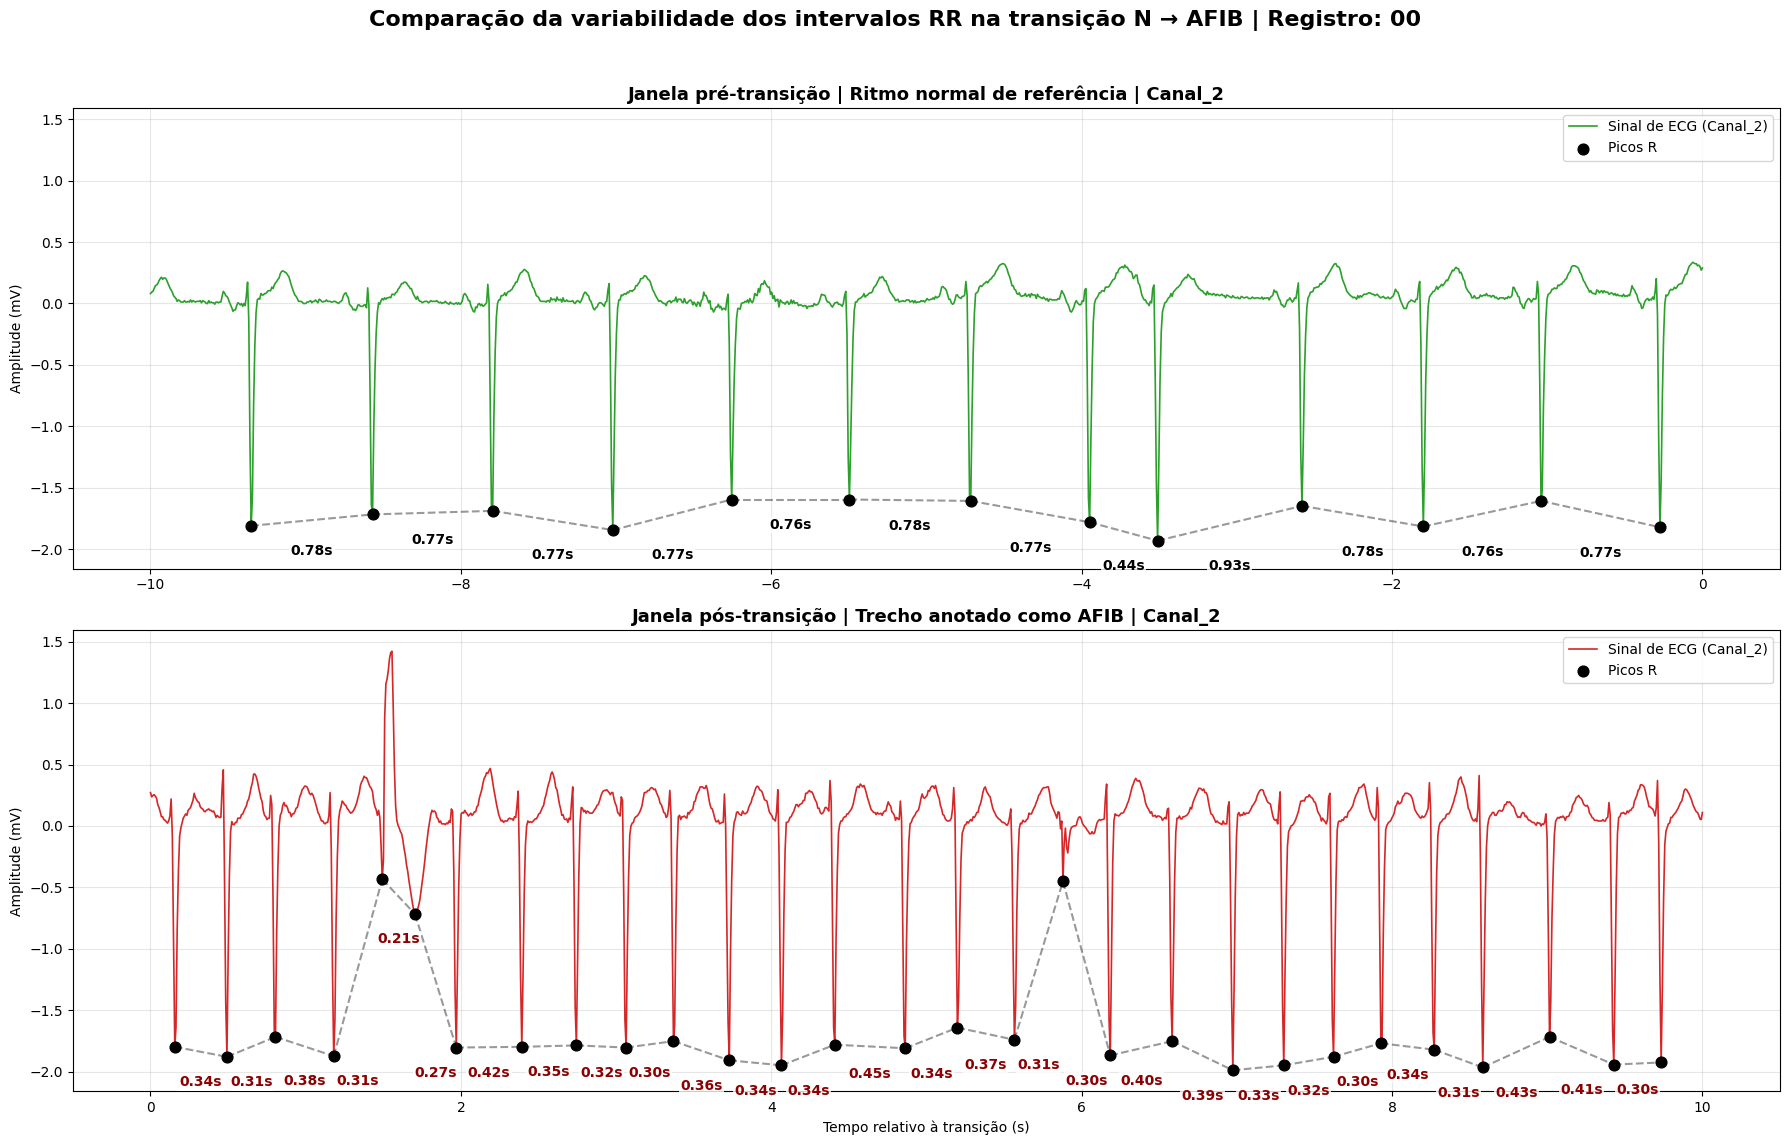

In [14]:
# Procura a primeira transição explícita N -> AFIB para comparar a regularidade dos intervalos RR.
normal_idx, afib_idx = find_normal_to_afib_transition(annotations)

if afib_idx is None:
    print('Nenhuma transição explícita de ritmo normal para AFIB foi encontrada neste registro.')
else:
    transition_sample = int(annotations.sample[afib_idx])
    sampling_frequency = record.fs
    channel_name = f'Canal_{plot_channel + 1}'

    # Janela imediatamente anterior à transição: usada como referência de ritmo normal.
    start_normal = max(0, transition_sample - int(10 * sampling_frequency))
    end_normal = transition_sample
    signal_normal = record.p_signal[start_normal:end_normal, plot_channel]
    time_normal = np.linspace(-len(signal_normal) / sampling_frequency, 0, len(signal_normal))

    # Janela imediatamente posterior à transição: usada como exemplo de AFIB.
    start_afib = transition_sample
    end_afib = min(record.sig_len, transition_sample + int(10 * sampling_frequency))
    signal_afib = record.p_signal[start_afib:end_afib, plot_channel]
    time_afib = np.linspace(0, len(signal_afib) / sampling_frequency, len(signal_afib))

    # Detecta picos R e deriva intervalos RR para evidenciar a diferença de regularidade.
    peaks_normal_idx, _ = detect_r_peaks(signal_normal, sampling_frequency, min_distance_seconds=0.30)
    peaks_afib_idx, _ = detect_r_peaks(signal_afib, sampling_frequency, min_distance_seconds=0.20)

    time_peaks_normal = time_normal[peaks_normal_idx] if len(peaks_normal_idx) else np.array([])
    values_peaks_normal = signal_normal[peaks_normal_idx] if len(peaks_normal_idx) else np.array([])
    time_peaks_afib = time_afib[peaks_afib_idx] if len(peaks_afib_idx) else np.array([])
    values_peaks_afib = signal_afib[peaks_afib_idx] if len(peaks_afib_idx) else np.array([])

    rr_normal = np.diff(time_peaks_normal) if len(time_peaks_normal) > 1 else np.array([])
    rr_afib = np.diff(time_peaks_afib) if len(time_peaks_afib) > 1 else np.array([])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), sharey=True)

    ax1.plot(time_normal, signal_normal, color='#2ca02c', lw=1.2, label=f'Sinal de ECG ({channel_name})')
    if len(time_peaks_normal):
        ax1.scatter(time_peaks_normal, values_peaks_normal, color='black', s=60, zorder=5, label='Picos R')

    for i in range(len(rr_normal)):
        x_mid = time_peaks_normal[i] + rr_normal[i] / 2
        y_pos = min(values_peaks_normal[i], values_peaks_normal[i + 1]) - 0.15
        ax1.plot(
            [time_peaks_normal[i], time_peaks_normal[i + 1]],
            [values_peaks_normal[i], values_peaks_normal[i + 1]],
            color='black',
            linestyle='--',
            alpha=0.4
        )
        ax1.text(
            x_mid, y_pos, f'{rr_normal[i]:.2f}s',
            ha='center', va='top',
            fontsize=10, color='black', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)
        )

    ax1.set_title(f'Janela pré-transição | Ritmo normal de referência | {channel_name}', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Amplitude (mV)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    ax2.plot(time_afib, signal_afib, color='#d62728', lw=1.2, label=f'Sinal de ECG ({channel_name})')
    if len(time_peaks_afib):
        ax2.scatter(time_peaks_afib, values_peaks_afib, color='black', s=60, zorder=5, label='Picos R')

    for i in range(len(rr_afib)):
        x_mid = time_peaks_afib[i] + rr_afib[i] / 2
        y_pos = min(values_peaks_afib[i], values_peaks_afib[i + 1]) - 0.15
        ax2.plot(
            [time_peaks_afib[i], time_peaks_afib[i + 1]],
            [values_peaks_afib[i], values_peaks_afib[i + 1]],
            color='black',
            linestyle='--',
            alpha=0.4
        )
        ax2.text(
            x_mid, y_pos, f'{rr_afib[i]:.2f}s',
            ha='center', va='top',
            fontsize=10, color='darkred', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)
        )

    ax2.set_title(f'Janela pós-transição | Trecho anotado como AFIB | {channel_name}', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Tempo relativo à transição (s)')
    ax2.set_ylabel('Amplitude (mV)')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')

    plt.suptitle(
        f'Comparação da variabilidade dos intervalos RR na transição N → AFIB | Registro: {selected_record_path.name}',
        fontsize=16,
        fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()


### 3.8 Comparação evolutiva por fases

Esta visualização compara janelas sucessivas de um trecho normal e de um trecho em AFIB dentro do mesmo registro.

Assim como na etapa anterior, o código evita depender de amostras fixas e tenta localizar automaticamente trechos compatíveis nas anotações, permitindo observar a persistência ou a variação do padrão ao longo do tempo.

In [15]:
# Busca automaticamente um trecho normal e um trecho AFIB para comparação evolutiva em múltiplas fases.
normal_start_idx = first_index_matching(annotations, '(N')
afib_start_idx = first_index_matching(annotations, '(AFIB')
phase_window_seconds = 10
total_phases = 4


class PhaseComparator:
    """Navegador para comparar, fase a fase, janelas normais e janelas AFIB."""

    def __init__(
        self,
        record,
        normal_start_sample,
        afib_start_sample,
        plot_channel,
        phase_window_seconds=10,
        total_phases=4
    ):
        self.record = record
        self.normal_start_sample = normal_start_sample
        self.afib_start_sample = afib_start_sample
        self.plot_channel = plot_channel
        self.phase_window_seconds = phase_window_seconds
        self.total_phases = total_phases
        self.current_phase = 0

        if self.normal_start_sample is None or self.afib_start_sample is None:
            print('Não foi possível montar a comparação em fases: faltam trechos normal ou AFIB nas anotações.')
            return

        self.btn_prev = widgets.Button(description='⬅️ Fase Anterior', layout=widgets.Layout(width='180px'))
        self.btn_next = widgets.Button(description='Próxima Fase ➡️', layout=widgets.Layout(width='180px'))
        self.output = widgets.Output()

        self.btn_prev.on_click(self.previous)
        self.btn_next.on_click(self.next)

        display(widgets.HBox([self.btn_prev, self.btn_next]), self.output)
        self.render()

    def plot_signal(self, ax, base_sample, color, title, is_afib=False):
        # Cada fase representa uma janela sucessiva deslocada no tempo.
        start_sample = base_sample + int(self.current_phase * self.phase_window_seconds * self.record.fs)
        end_sample = min(self.record.sig_len, start_sample + int(self.phase_window_seconds * self.record.fs))

        signal = self.record.p_signal[start_sample:end_sample, self.plot_channel]
        time_axis = np.linspace(
            self.current_phase * self.phase_window_seconds,
            self.current_phase * self.phase_window_seconds + len(signal) / self.record.fs,
            len(signal)
        )

        peak_distance = 0.20 if is_afib else 0.30
        peak_indices, _ = detect_r_peaks(signal, self.record.fs, min_distance_seconds=peak_distance)

        peak_times = time_axis[peak_indices] if len(peak_indices) else np.array([])
        peak_values = signal[peak_indices] if len(peak_indices) else np.array([])
        rr_intervals = np.diff(peak_times) if len(peak_times) > 1 else np.array([])

        ax.plot(time_axis, signal, color=color, lw=1.2, label=title)
        if len(peak_times):
            ax.scatter(peak_times, peak_values, color='black', s=40, zorder=5)

        # Sobrepõe os intervalos RR diretamente sobre o gráfico para facilitar a leitura visual.
        for i in range(len(rr_intervals)):
            x_mid = peak_times[i] + rr_intervals[i] / 2
            y_pos = min(peak_values[i], peak_values[i + 1]) - 0.2
            ax.plot(
                [peak_times[i], peak_times[i + 1]],
                [peak_values[i], peak_values[i + 1]],
                color='black',
                linestyle='--',
                alpha=0.3
            )
            ax.text(
                x_mid, y_pos, f'{rr_intervals[i]:.2f}s',
                ha='center', va='top',
                fontsize=9, color='black', fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
            )

        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel('Amplitude (mV)')
        ax.grid(True, alpha=0.2)
        if len(time_axis):
            ax.set_xlim(time_axis[0], time_axis[-1])

    def render(self):
        with self.output:
            clear_output(wait=True)
            fig, (ax_normal, ax_afib) = plt.subplots(2, 1, figsize=(18, 12), sharex=False)

            self.plot_signal(
                ax_normal,
                self.normal_start_sample,
                '#2ca02c',
                f'Fase {self.current_phase + 1} | Ritmo normal de referência',
                is_afib=False,
            )
            self.plot_signal(
                ax_afib,
                self.afib_start_sample,
                '#d62728',
                f'Fase {self.current_phase + 1} | Trecho anotado como AFIB',
                is_afib=True,
            )

            plt.xlabel('Tempo acumulado dentro da comparação (s)')
            plt.suptitle(
                f'Comparação evolutiva entre ritmo normal e AFIB | Registro: {selected_record_path.name} | '
                f'Fase {self.current_phase + 1} de {self.total_phases}',
                fontsize=16,
                fontweight='bold'
            )
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

    def next(self, _):
        if self.current_phase < self.total_phases - 1:
            self.current_phase += 1
            self.render()

    def previous(self, _):
        if self.current_phase > 0:
            self.current_phase -= 1
            self.render()


normal_start_sample = int(annotations.sample[normal_start_idx]) if normal_start_idx is not None else None
afib_start_sample = int(annotations.sample[afib_start_idx]) if afib_start_idx is not None else None

comparador_fases = PhaseComparator(
    record=record,
    normal_start_sample=normal_start_sample,
    afib_start_sample=afib_start_sample,
    plot_channel=plot_channel,
    phase_window_seconds=phase_window_seconds,
    total_phases=total_phases,
)


Output()

### 3.9 Interpretação dos achados e próximos passos

Observando a comparação entre um período de arritmia marcado por um especialista e um período de batimento regular, concluímos que um dos fatores mais relevantes para essa distinção é a **variabilidade do intervalo R-R**, isto é, a diferença de tempo entre batimentos consecutivos.

A partir da extração matemática desses intervalos em janelas temporais, identificamos o seguinte padrão:

**Ritmo regular (referência):** a variação de tempo entre um batimento e o seguinte manteve-se muito estável, com oscilações pequenas e consistentes ao longo da maior parte do trecho analisado.

**Fibrilação atrial (arritmia):** o tempo entre os batimentos mostrou-se significativamente mais irregular, com mudanças abruptas entre intervalos consecutivos, o que reforça o caráter caótico típico do traçado em AFIB.

Com base nessa inspeção visual e matemática, definimos três diretrizes fundamentais para a arquitetura dos modelos na próxima fase (Sprint 3):

1. **Compromisso da janela temporal:** a AFIB pode apresentar pequenas janelas momentaneamente estáveis. Janelas muito curtas podem induzir falsos negativos; janelas muito longas podem esconder detalhes morfológicos importantes. Por isso, o intervalo padronizado de **10 segundos** mostrou-se um bom equilíbrio para esta etapa.

2. **Foco em métricas de dispersão:** a modelagem não deve priorizar apenas a média da frequência cardíaca (BPM), mas também medidas de **dispersão, variância e irregularidade** dos intervalos entre picos detectados.

3. **Escolha do canal com melhor relação sinal-ruído:** para extração de features matemáticas, o **Canal 2** tende a oferecer linha de base mais estável e menor ruído de alta frequência, o que favorece a demarcação automática dos picos R e melhora a robustez analítica do pipeline.


## 4. Preparação para Modelagem

Nesta etapa, a análise deixa de ser apenas exploratória e passa a construir uma base pronta para treinar modelos de classificação de fibrilação atrial (AFIB).

A estratégia adotada será baseada em **intervalos RR**, isto é, nos tempos entre picos R consecutivos. Essa escolha é adequada para AFIB porque a arritmia costuma produzir uma sequência de batimentos **irregularmente irregular**, o que aparece de forma mais clara nos RR do que em janelas fixas de poucos segundos.

As decisões metodológicas desta seção são:

- usar **janelas por número de batimentos**, e não apenas por segundos;
- começar com **32 intervalos RR por janela**, com **sobreposição de 16 RR**;
- descartar janelas ambíguas, isto é, que não sejam majoritariamente AFIB nem majoritariamente normais;
- comparar janelas candidatas de diferentes tamanhos e escolher a melhor com base em **recall**, usando **F1-score** como critério secundário.


O pipeline será composto por:

1. filtragem do sinal;
2. escolha automática do melhor canal;
3. detecção de picos R;
4. cálculo dos intervalos RR;
5. construção de janelas;
6. rotulagem com base nas anotações do exame;
7. extração de features de irregularidade;
8. comparação entre tamanhos de janela.

In [16]:
# ============================================================
# 4.1 Configurações da preparação para modelagem
# ============================================================

RR_WINDOW_BEATS = 32
RR_STEP_BEATS = 16
LABEL_THRESHOLD = 0.80          # 80% da janela precisa ser AFIB ou NORMAL
MAX_INVALID_RR_RATIO = 0.20     # se mais de 20% dos RR da janela forem inválidos, descarta
CANDIDATE_WINDOWS = [16, 32, 64]

### 4.1 Funções auxiliares para filtragem, escolha de canal e construção de janelas RR

Antes de montar a base final, precisamos criar algumas funções auxiliares.

Primeiro, aplicamos um **filtro passa-banda** para deixar o sinal mais adequado à detecção dos complexos QRS. Em seguida, escolhemos automaticamente o **melhor canal** do exame com base em um critério simples de qualidade: quantidade de picos detectados, proporção de intervalos RR fisiologicamente plausíveis e ausência de trechos degenerados.

Depois disso, construímos os **segmentos de ritmo** a partir das anotações, rotulamos cada janela como `AFIB`, `NORMAL` ou `IGNORE`, e finalmente extraímos features clássicas dos RR, como:

- média e mediana;
- desvio-padrão;
- RMSSD;
- pNN50;
- coeficiente de variação;
- IQR.

Essas features são particularmente úteis porque resumem a irregularidade temporal dos batimentos, que é uma das principais assinaturas da fibrilação atrial.

In [17]:
# ============================================================
# 4.2 Funções auxiliares de pré-processamento e extração RR
# ============================================================

def butter_bandpass(lowcut, highcut, fs, order=3):
    nyq = 0.5 * fs
    low = max(lowcut / nyq, 1e-6)
    high = min(highcut / nyq, 0.999)
    b, a = butter(order, [low, high], btype='band')
    return b, a


def bandpass_filter(signal, fs, lowcut, highcut, order=3):
    signal = np.asarray(signal, dtype=float)

    if np.isnan(signal).any():
        signal = pd.Series(signal).interpolate(limit_direction='both').to_numpy()

    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return filtfilt(b, a, signal)


def build_rhythm_segments(record, annotations):
    """
    Converte as anotações de mudança de ritmo em segmentos contínuos.
    Cada segmento recebe um rótulo simplificado: AFIB, NORMAL ou OTHER.
    """
    if annotations is None:
        return pd.DataFrame(columns=['start_sample', 'end_sample', 'raw_label', 'label'])

    segments = []
    rhythm_indices = get_rhythm_indices(annotations)

    for position, current_idx in enumerate(rhythm_indices):
        start_sample = int(annotations.sample[current_idx])

        if position + 1 < len(rhythm_indices):
            end_sample = int(annotations.sample[rhythm_indices[position + 1]])
        else:
            end_sample = int(record.sig_len)

        raw_note = clean_note(annotations.aux_note[current_idx]).replace('(', '')

        if 'AFIB' in raw_note:
            label = 'AFIB'
        elif raw_note.startswith('N'):
            label = 'NORMAL'
        else:
            label = 'OTHER'

        segments.append({
            'start_sample': start_sample,
            'end_sample': end_sample,
            'raw_label': raw_note,
            'label': label
        })

    return pd.DataFrame(segments)


def label_window_by_segments(start_sample, end_sample, segments_df, threshold=0.80):
    """
    Rotula uma janela com base na sobreposição temporal com os segmentos anotados.
    A janela só recebe AFIB ou NORMAL se pelo menos 80% do seu intervalo estiver
    dentro daquela classe. Caso contrário, vira IGNORE.
    """
    window_len = max(1, end_sample - start_sample)

    afib_overlap = 0
    normal_overlap = 0

    for row in segments_df.itertuples(index=False):
        overlap_start = max(start_sample, row.start_sample)
        overlap_end = min(end_sample, row.end_sample)
        overlap = max(0, overlap_end - overlap_start)

        if overlap == 0:
            continue

        if row.label == 'AFIB':
            afib_overlap += overlap
        elif row.label == 'NORMAL':
            normal_overlap += overlap

    afib_ratio = afib_overlap / window_len
    normal_ratio = normal_overlap / window_len

    if afib_ratio >= threshold:
        return 'AFIB', afib_ratio, normal_ratio
    if normal_ratio >= threshold:
        return 'NORMAL', afib_ratio, normal_ratio

    return 'IGNORE', afib_ratio, normal_ratio


def rr_features(rr):
    """
    Extrai features estatísticas e de irregularidade dos intervalos RR.
    Essas features serão a base tabular usada para classificação.
    """
    rr = np.asarray(rr, dtype=float)
    rr = rr[np.isfinite(rr)]

    if len(rr) < 4:
        return None

    diff_rr = np.diff(rr)
    abs_diff_rr = np.abs(diff_rr)

    return {
        'rr_mean': np.mean(rr),
        'rr_median': np.median(rr),
        'rr_std': np.std(rr, ddof=1) if len(rr) > 1 else 0.0,
        'rr_min': np.min(rr),
        'rr_max': np.max(rr),
        'rr_iqr': iqr(rr),
        'rr_cv': np.std(rr, ddof=1) / np.mean(rr) if np.mean(rr) > 0 else np.nan,
        'rmssd': np.sqrt(np.mean(diff_rr**2)) if len(diff_rr) > 0 else np.nan,
        'pnn50': np.mean(abs_diff_rr > 0.05) if len(abs_diff_rr) > 0 else np.nan,
        'diff_abs_mean': np.mean(abs_diff_rr) if len(abs_diff_rr) > 0 else np.nan,
        'rr_valid_count': len(rr)
    }


def channel_quality_from_rr(signal, fs):
    """
    Gera um score simples de qualidade para cada canal.
    A ideia é favorecer canais com:
    - mais picos detectáveis;
    - maior proporção de RR plausíveis;
    - menor evidência de flatline.
    """
    filtered = bandpass_filter(signal, fs, 5, 18)
    peaks, polarity = detect_r_peaks(filtered, fs, min_distance_seconds=0.25)

    if len(peaks) < 10:
        return {
            'score': -np.inf,
            'n_peaks': len(peaks),
            'valid_rr_ratio': 0.0,
            'flat_ratio': np.nan,
            'polarity': polarity
        }

    rr = np.diff(peaks) / fs
    valid_rr = (rr >= 0.30) & (rr <= 2.00)
    flat_ratio = np.mean(np.isclose(np.diff(signal), 0.0))

    score = (
        valid_rr.mean()
        + 0.001 * len(peaks)
        - 2.0 * flat_ratio
    )

    return {
        'score': score,
        'n_peaks': len(peaks),
        'valid_rr_ratio': valid_rr.mean(),
        'flat_ratio': flat_ratio,
        'polarity': polarity
    }


def choose_best_channel(record):
    """
    Seleciona automaticamente o melhor canal do exame para análise RR.
    """
    rows = []

    for channel_index in range(record.n_sig):
        signal = record.p_signal[:, channel_index]
        stats = channel_quality_from_rr(signal, record.fs)

        rows.append({
            'channel_index': channel_index,
            'channel_name': record.sig_name[channel_index] if hasattr(record, 'sig_name') else f'Canal_{channel_index + 1}',
            **stats
        })

    df = pd.DataFrame(rows).sort_values('score', ascending=False).reset_index(drop=True)
    best_channel_index = int(df.iloc[0]['channel_index'])
    return best_channel_index, df


def build_rr_windows_for_record(
    record_path,
    rr_window_beats=32,
    rr_step_beats=16,
    label_threshold=0.80,
    max_invalid_rr_ratio=0.20
):
    """
    Pipeline principal para um único registro:
    1. carrega o exame;
    2. escolhe o melhor canal;
    3. filtra o sinal;
    4. detecta picos R;
    5. calcula RR;
    6. monta janelas;
    7. extrai features;
    8. atribui rótulos.
    """
    record, annotations = load_record(record_path)

    best_channel, channel_quality_df = choose_best_channel(record)
    raw_signal = record.p_signal[:, best_channel]

    # Filtragem voltada para realce de QRS
    qrs_signal = bandpass_filter(raw_signal, record.fs, 5, 18)

    # Detecção de picos R
    peaks, polarity = detect_r_peaks(qrs_signal, record.fs, min_distance_seconds=0.25)

    if len(peaks) < rr_window_beats + 1:
        return pd.DataFrame(), channel_quality_df

    rr_all = np.diff(peaks) / record.fs
    valid_rr_mask = (rr_all >= 0.30) & (rr_all <= 2.00)

    segments_df = build_rhythm_segments(record, annotations)

    rows = []

    for start in range(0, len(rr_all) - rr_window_beats + 1, rr_step_beats):
        end = start + rr_window_beats

        rr_window = rr_all[start:end]
        valid_window = valid_rr_mask[start:end]

        invalid_ratio = 1.0 - valid_window.mean()

        if invalid_ratio > max_invalid_rr_ratio:
            continue

        rr_clean = rr_window[valid_window]
        features = rr_features(rr_clean)

        if features is None:
            continue

        start_sample = int(peaks[start])
        end_sample = int(peaks[end])

        label, afib_ratio, normal_ratio = label_window_by_segments(
            start_sample=start_sample,
            end_sample=end_sample,
            segments_df=segments_df,
            threshold=label_threshold
        )

        if label == 'IGNORE':
            continue

        rows.append({
            'record': record_path.name,
            'channel_index': best_channel,
            'window_start_s': start_sample / record.fs,
            'window_end_s': end_sample / record.fs,
            'window_seconds': (end_sample - start_sample) / record.fs,
            'label': label,
            'afib_ratio': afib_ratio,
            'normal_ratio': normal_ratio,
            'invalid_rr_ratio': invalid_ratio,
            **features
        })

    return pd.DataFrame(rows), channel_quality_df

### 4.2 Validação inicial em um único registro

Antes de processar toda a base, é importante validar o pipeline em apenas um exame.

In [19]:
# ============================================================
# 4.3 Teste do pipeline em um único registro
# ============================================================

df_rr_selected, df_channel_quality = build_rr_windows_for_record(
    selected_record_path,
    rr_window_beats=RR_WINDOW_BEATS,
    rr_step_beats=RR_STEP_BEATS,
    label_threshold=LABEL_THRESHOLD,
    max_invalid_rr_ratio=MAX_INVALID_RR_RATIO
)

print('=== QUALIDADE DOS CANAIS ===')
display(df_channel_quality)

print('\n=== AMOSTRA DAS JANELAS RR ===')
display(df_rr_selected.head().T)

print('\n=== DISTRIBUIÇÃO DOS RÓTULOS ===')
if not df_rr_selected.empty:
    print(df_rr_selected['label'].value_counts(dropna=False))
else:
    print('Nenhuma janela válida foi gerada para o registro selecionado.')

print('\n=== DURAÇÃO DAS JANELAS EM SEGUNDOS ===')
if not df_rr_selected.empty:
    display(df_rr_selected['window_seconds'].describe())
else:
    print('Sem estatísticas de duração porque nenhuma janela foi gerada.')

=== QUALIDADE DOS CANAIS ===


,channel_index,channel_name,score,n_peaks,valid_rr_ratio,flat_ratio,polarity
0,0,ECG,110.94585,110155,0.965630,0.087390,1
1,1,ECG,109.93742,109211,0.963831,0.118706,-1



=== AMOSTRA DAS JANELAS RR ===


,0,1,2,3,4
record,00,00,00,00,00
channel_index,0,0,0,0,0
window_start_s,654.195312,667.046875,696.570312,707.171875,719.726562
window_end_s,679.976562,688.523438,719.726562,733.515625,747.257812
window_seconds,25.78125,21.476562,23.15625,26.34375,27.53125
label,NORMAL,NORMAL,NORMAL,NORMAL,NORMAL
afib_ratio,0.0,0.0,0.0,0.0,0.0
normal_ratio,1.0,1.0,1.0,1.0,1.0
invalid_rr_ratio,0.03125,0.09375,0.0625,0.0,0.0
rr_mean,0.822581,0.710938,0.753125,0.823242,0.860352



=== DISTRIBUIÇÃO DOS RÓTULOS ===
label
NORMAL    5421
AFIB      1216
Name: count, dtype: int64

=== DURAÇÃO DAS JANELAS EM SEGUNDOS ===


count    6637.000000
mean       22.203734
std         5.581596
min        10.828125
25%        19.539062
50%        24.625000
75%        26.273438
max        30.164062
Name: window_seconds, dtype: float64

### 4.3 Construção da base RR para todos os registros

Depois de validar o pipeline em um exame, aplicamos o mesmo processo a todos os registros disponíveis.

Ao final desta etapa, teremos uma base tabular em que cada linha representa uma janela RR rotulada como `AFIB` ou `NORMAL`, acompanhada das features calculadas. Essa base servirá como entrada para o modelo de classificação.

In [20]:
# ============================================================
# 4.4 Montagem da base RR para todos os registros
# ============================================================

all_rr_windows = []
all_channel_quality = []

for record_path in record_paths:
    try:
        df_record, df_quality = build_rr_windows_for_record(
            record_path,
            rr_window_beats=RR_WINDOW_BEATS,
            rr_step_beats=RR_STEP_BEATS,
            label_threshold=LABEL_THRESHOLD,
            max_invalid_rr_ratio=MAX_INVALID_RR_RATIO
        )

        if not df_record.empty:
            all_rr_windows.append(df_record)

        df_quality = df_quality.copy()
        df_quality['record'] = record_path.name
        all_channel_quality.append(df_quality)

    except Exception as e:
        print(f'Erro no registro {record_path.name}: {e}')

dataset_rr = pd.concat(all_rr_windows, ignore_index=True) if all_rr_windows else pd.DataFrame()
dataset_channel_quality = pd.concat(all_channel_quality, ignore_index=True) if all_channel_quality else pd.DataFrame()

print('=== DATASET RR ===')
print(dataset_rr.shape)
display(dataset_rr.head())

print('\n=== DISTRIBUIÇÃO DAS CLASSES ===')
if not dataset_rr.empty:
    print(dataset_rr['label'].value_counts())
else:
    print('Nenhuma janela válida foi gerada para a base completa.')

print('\n=== DURAÇÃO DAS JANELAS ===')
if not dataset_rr.empty:
    display(dataset_rr['window_seconds'].describe())
else:
    print('Sem estatísticas de duração.')

=== DATASET RR ===
(12282, 20)


,record,channel_index,window_start_s,window_end_s,window_seconds,label,afib_ratio,normal_ratio,invalid_rr_ratio,rr_mean,rr_median,rr_std,rr_min,rr_max,rr_iqr,rr_cv,rmssd,pnn50,diff_abs_mean,rr_valid_count
0,00,0,654.195312,679.976562,25.781250,NORMAL,0.0,1.0,0.03125,0.822581,0.859375,0.119256,0.343750,0.898438,0.023438,0.144978,0.140813,0.166667,0.069271,31
1,00,0,667.046875,688.523438,21.476562,NORMAL,0.0,1.0,0.09375,0.710938,0.843750,0.206594,0.304688,0.898438,0.304688,0.290594,0.246465,0.571429,0.177734,29
2,00,0,696.570312,719.726562,23.156250,NORMAL,0.0,1.0,0.06250,0.753125,0.820312,0.158359,0.320312,0.859375,0.039062,0.210269,0.190197,0.344828,0.114763,30
3,00,0,707.171875,733.515625,26.343750,NORMAL,0.0,1.0,0.00000,0.823242,0.851562,0.112056,0.320312,0.882812,0.023438,0.136115,0.113344,0.096774,0.047631,32
4,00,0,719.726562,747.257812,27.531250,NORMAL,0.0,1.0,0.00000,0.860352,0.859375,0.013568,0.835938,0.882812,0.017578,0.015770,0.020765,0.000000,0.017893,32



=== DISTRIBUIÇÃO DAS CLASSES ===
label
NORMAL    6209
AFIB      6073
Name: count, dtype: int64

=== DURAÇÃO DAS JANELAS ===


count    12282.000000
mean        22.886721
std          5.521256
min         10.828125
25%         19.070312
50%         24.710938
75%         26.687500
max         37.312500
Name: window_seconds, dtype: float64

### 4.4 Limpeza final da base tabular

Mesmo após o pré-processamento, ainda é importante aplicar uma limpeza final na base de features.

Nesta etapa:

- removemos duplicatas;
- mantemos apenas janelas com rótulos válidos (`AFIB` e `NORMAL`);
- descartamos valores residuais absurdos;
- organizamos as colunas de entrada do modelo.

Essa limpeza reduz ruído e melhora a consistência da base usada no treinamento.

In [21]:
# ============================================================
# 4.5 Limpeza final da base de features
# ============================================================

feature_columns = [
    'rr_mean', 'rr_median', 'rr_std', 'rr_min', 'rr_max',
    'rr_iqr', 'rr_cv', 'rmssd', 'pnn50', 'diff_abs_mean',
    'rr_valid_count', 'invalid_rr_ratio'
]

dataset_rr = dataset_rr.copy()

if not dataset_rr.empty:
    dataset_rr = dataset_rr.drop_duplicates()

    dataset_rr = dataset_rr[dataset_rr['label'].isin(['AFIB', 'NORMAL'])]

    dataset_rr = dataset_rr[
        (dataset_rr['rr_mean'] >= 0.30) &
        (dataset_rr['rr_mean'] <= 2.00)
    ]

    dataset_rr = dataset_rr.reset_index(drop=True)

print('=== DATASET LIMPO ===')
print(dataset_rr.shape)
display(dataset_rr[feature_columns + ['label', 'record']].head() if not dataset_rr.empty else dataset_rr)

=== DATASET LIMPO ===
(12282, 20)


,rr_mean,rr_median,rr_std,rr_min,rr_max,rr_iqr,rr_cv,rmssd,pnn50,diff_abs_mean,rr_valid_count,invalid_rr_ratio,label,record
0,0.822581,0.859375,0.119256,0.343750,0.898438,0.023438,0.144978,0.140813,0.166667,0.069271,31,0.03125,NORMAL,00
1,0.710938,0.843750,0.206594,0.304688,0.898438,0.304688,0.290594,0.246465,0.571429,0.177734,29,0.09375,NORMAL,00
2,0.753125,0.820312,0.158359,0.320312,0.859375,0.039062,0.210269,0.190197,0.344828,0.114763,30,0.06250,NORMAL,00
3,0.823242,0.851562,0.112056,0.320312,0.882812,0.023438,0.136115,0.113344,0.096774,0.047631,32,0.00000,NORMAL,00
4,0.860352,0.859375,0.013568,0.835938,0.882812,0.017578,0.015770,0.020765,0.000000,0.017893,32,0.00000,NORMAL,00


### 4.5 Comparação entre tamanhos de janela

Agora vamos testar diferentes tamanhos de janela RR para descobrir qual oferece o melhor desempenho.

As janelas candidatas são:

- 16 RR;
- 32 RR;
- 64 RR.

A comparação será feita com validação cruzada agrupada por registro, o que evita vazamento de informação entre treino e teste. Isso é importante porque várias janelas do mesmo exame são muito correlacionadas.

Como o objetivo clínico é **não perder episódios verdadeiros de AFIB**, o critério principal de escolha será o **recall**. O **F1-score** será usado como apoio para equilibrar recall e precisão.

In [24]:
# ============================================================
# 4.6 Avaliação de janelas candidatas
# ============================================================

def evaluate_window_candidates(record_paths, candidate_windows=(16, 32, 64)):
    results = []

    for rr_window_beats in candidate_windows:
        rr_step_beats = max(1, rr_window_beats // 2)

        all_data = []

        for record_path in record_paths:
            df_record, _ = build_rr_windows_for_record(
                record_path,
                rr_window_beats=rr_window_beats,
                rr_step_beats=rr_step_beats,
                label_threshold=LABEL_THRESHOLD,
                max_invalid_rr_ratio=MAX_INVALID_RR_RATIO
            )

            if not df_record.empty:
                all_data.append(df_record)

        if not all_data:
            continue

        df_candidate = pd.concat(all_data, ignore_index=True)
        df_candidate = df_candidate[df_candidate['label'].isin(['AFIB', 'NORMAL'])].copy()

        if df_candidate.empty or df_candidate['label'].nunique() < 2:
            continue

        X = df_candidate[feature_columns]
        y = (df_candidate['label'] == 'AFIB').astype(int)
        groups = df_candidate['record']

        n_groups = groups.nunique()
        if n_groups < 2:
            continue

        n_splits = min(5, n_groups)
        cv = GroupKFold(n_splits=n_splits)

        model = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
        ])

        scores = cross_validate(
            model,
            X,
            y,
            groups=groups,
            cv=cv,
            scoring={
                'recall': 'recall',
                'precision': 'precision',
                'f1': 'f1'
            }
        )

        results.append({
            'rr_window_beats': rr_window_beats,
            'rr_step_beats': rr_step_beats,
            'n_windows': len(df_candidate),
            'mean_window_seconds': df_candidate['window_seconds'].mean(),
            'recall_mean': np.mean(scores['test_recall']),
            'precision_mean': np.mean(scores['test_precision']),
            'f1_mean': np.mean(scores['test_f1'])
        })

    if not results:
        return pd.DataFrame()

    return pd.DataFrame(results).sort_values(
        ['recall_mean', 'f1_mean', 'precision_mean'],
        ascending=False
    ).reset_index(drop=True)


df_window_eval = evaluate_window_candidates(record_paths, CANDIDATE_WINDOWS)

print('=== COMPARAÇÃO ENTRE JANELAS RR ===')
display(df_window_eval)

=== COMPARAÇÃO ENTRE JANELAS RR ===


,rr_window_beats,rr_step_beats,n_windows,mean_window_seconds,recall_mean,precision_mean,f1_mean
0,64,32,6186,45.659790,0.551717,0.715864,0.397162
1,16,8,24445,11.477249,0.536839,0.611148,0.269524
2,32,16,12282,22.886721,0.534487,0.676105,0.330989


### 4.6 Escolha da melhor janela

Com os resultados em mãos, escolhemos automaticamente a melhor janela seguindo a lógica abaixo:

1. maior **recall médio**;
2. em caso de empate, maior **F1-score**;
3. depois, maior **precisão**.

Na prática, espera-se que **32 RR** apareça como uma solução de equilíbrio entre estabilidade estatística e capacidade de captar mudanças de ritmo, mas a decisão final será baseada nos resultados obtidos.

In [25]:
# ============================================================
# 4.7 Escolha automática da melhor janela
# ============================================================

if df_window_eval.empty:
    print('Não foi possível comparar as janelas candidatas.')
    best_rr_window = RR_WINDOW_BEATS
    best_rr_step = RR_STEP_BEATS
else:
    best_window_row = df_window_eval.iloc[0]
    best_rr_window = int(best_window_row['rr_window_beats'])
    best_rr_step = int(best_window_row['rr_step_beats'])

    print('=== JANELA ESCOLHIDA ===')
    print(f'RR por janela: {best_rr_window}')
    print(f'Passo entre janelas: {best_rr_step}')
    print(f'Recall médio: {best_window_row["recall_mean"]:.4f}')
    print(f'F1 médio: {best_window_row["f1_mean"]:.4f}')
    print(f'Precisão média: {best_window_row["precision_mean"]:.4f}')
    print(f'Duração média em segundos: {best_window_row["mean_window_seconds"]:.2f}')

=== JANELA ESCOLHIDA ===
RR por janela: 64
Passo entre janelas: 32
Recall médio: 0.5517
F1 médio: 0.3972
Precisão média: 0.7159
Duração média em segundos: 45.66


### 4.7 Geração da base final para modelagem

Depois de escolher a melhor janela, o último passo é reconstruir a base completa usando essa configuração vencedora.

Essa será a base final usada para experimentos de classificação supervisionada, comparação entre modelos e análise das métricas principais do projeto.

In [26]:
# ============================================================
# 4.8 Geração da base final usando a melhor janela
# ============================================================

FINAL_RR_WINDOW = best_rr_window
FINAL_RR_STEP = best_rr_step

final_rr_windows = []

for record_path in record_paths:
    df_record, _ = build_rr_windows_for_record(
        record_path,
        rr_window_beats=FINAL_RR_WINDOW,
        rr_step_beats=FINAL_RR_STEP,
        label_threshold=LABEL_THRESHOLD,
        max_invalid_rr_ratio=MAX_INVALID_RR_RATIO
    )

    if not df_record.empty:
        final_rr_windows.append(df_record)

final_dataset_rr = pd.concat(final_rr_windows, ignore_index=True) if final_rr_windows else pd.DataFrame()

if not final_dataset_rr.empty:
    final_dataset_rr = final_dataset_rr[final_dataset_rr['label'].isin(['AFIB', 'NORMAL'])].reset_index(drop=True)

print('=== BASE FINAL ===')
print(final_dataset_rr.shape)
display(final_dataset_rr.head())

print('\n=== DISTRIBUIÇÃO FINAL DAS CLASSES ===')
if not final_dataset_rr.empty:
    print(final_dataset_rr['label'].value_counts())
else:
    print('A base final ficou vazia.')

=== BASE FINAL ===
(6186, 20)


,record,channel_index,window_start_s,window_end_s,window_seconds,label,afib_ratio,normal_ratio,invalid_rr_ratio,rr_mean,rr_median,rr_std,rr_min,rr_max,rr_iqr,rr_cv,rmssd,pnn50,diff_abs_mean,rr_valid_count
0,00,0,654.195312,696.570312,42.375000,NORMAL,0.0,1.0,0.140625,0.725000,0.843750,0.192194,0.304688,0.898438,0.296875,0.265095,0.214992,0.481481,0.144387,55
1,00,0,679.976562,719.726562,39.750000,NORMAL,0.0,1.0,0.156250,0.684606,0.804688,0.191109,0.304688,0.875000,0.318359,0.279152,0.231997,0.566038,0.164947,54
2,00,0,696.570312,747.257812,50.687500,NORMAL,0.0,1.0,0.031250,0.808468,0.843750,0.122205,0.320312,0.882812,0.037109,0.151156,0.131989,0.163934,0.063909,62
3,00,0,719.726562,775.500000,55.773438,NORMAL,0.0,1.0,0.000000,0.871460,0.875000,0.016930,0.835938,0.898438,0.023438,0.019427,0.021248,0.000000,0.018849,64
4,00,0,747.257812,803.218750,55.960938,NORMAL,0.0,1.0,0.000000,0.874390,0.890625,0.078648,0.445312,0.921875,0.023438,0.089946,0.082486,0.031746,0.031374,64



=== DISTRIBUIÇÃO FINAL DAS CLASSES ===
label
NORMAL    3117
AFIB      3069
Name: count, dtype: int64


### 4.8 Interpretação da escolha da janela

Ao final da comparação, a janela escolhida representa o melhor compromisso entre:

- estabilidade estatística das features RR;
- sensibilidade para detectar episódios de AFIB;
- equilíbrio entre recall e precisão.

Em geral, janelas muito curtas tendem a ser mais sensíveis a variações locais e ruído, enquanto janelas muito longas podem diluir episódios curtos de arritmia. Por isso, a comparação empírica entre 16, 32 e 64 RR é importante para justificar a escolha metodológica do trabalho.

A partir deste ponto, a base está pronta para alimentar modelos supervisionados, como regressão logística, árvores, random forests ou outros classificadores apropriados.